# Thesis Figure Generation
**Classification of Cancer Driver vs Passenger Mutations Using Sequence and Genomic Context Features**

This notebook is a self-contained pipeline that:
1. Loads the preprocessed COSMIC dataset
2. Performs feature engineering (identical to the main notebook)
3. Trains the ML models
4. Generates **all thesis figures** organized into chapter folders

**Output:**
```
thesis_figures/
├── ch4_data/           # EDA & Data Description
├── ch5_methodology/    # Pipeline diagrams
├── ch6_results/        # Model results
└── appendix/           # Supplementary
```

> **Note:** Run this notebook after the main `cancer_mutation_classification.ipynb` has been executed at least once (so preprocessed data exists).

## 1. Environment Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Create output directories
CH4_DIR = 'thesis_figures/ch4_data'
CH5_DIR = 'thesis_figures/ch5_methodology'
CH6_DIR = 'thesis_figures/ch6_results'
APPENDIX_DIR = 'thesis_figures/appendix'

for d in [CH4_DIR, CH5_DIR, CH6_DIR, APPENDIX_DIR]:
    os.makedirs(d, exist_ok=True)

print('All imports successful. Output directories created.')

All imports successful. Output directories created.


## 2. Data Loading & Preprocessing
Load the preprocessed COSMIC dataset, deduplicate, and sample 500K rows (matching the main notebook).

In [2]:
DATA_FILE = 'preprocessed data/gsm_clean_with_cgc.tsv'

gsm_df = pd.read_csv(DATA_FILE, sep='\t')
print(f'Raw: {gsm_df.shape[0]:,} rows')

gsm_df = gsm_df.drop_duplicates()
gsm_df = gsm_df.sample(n=500000, random_state=42)
print(f'After dedup + sample: {gsm_df.shape[0]:,} rows')
print(f'Class balance: {gsm_df["is_CGC"].value_counts(normalize=True).to_dict()}')

Raw: 13,617,032 rows
After dedup + sample: 500,000 rows
Class balance: {0: 0.921422, 1: 0.078578}


## 3. Feature Engineering
Reproduce the exact same feature engineering pipeline from the main notebook.

In [3]:
# --- Mutation Type ---
gsm_df['MUTATION_TYPE'] = gsm_df['MUTATION_DESCRIPTION'].str.split(',').str[0]

# --- Sample weights (ignore non-protein-altering) ---
ignore_types = ['intron_variant', '3_prime_UTR_variant', '5_prime_UTR_variant']
sample_weights = np.where(gsm_df['MUTATION_TYPE'].isin(ignore_types), 0, 1)

# --- Amino Acid parsing ---
def classify_aa(aa):
    groups = {
        'nonpolar': set('GAVILMPF'),
        'aromatic': set('WYF'),
        'polar': set('STNQC'),
        'negative': set('DE'),
        'positive': set('KRH'),
    }
    for name, chars in groups.items():
        if aa in chars:
            return name
    return 'unknown'

aa_parsed = gsm_df['MUTATION_AA'].str.extract(r'p\.([A-Z\*])(\d+)([A-Z\*])?')
gsm_df['AA_REF'] = aa_parsed[0]
gsm_df['AA_POSITION'] = pd.to_numeric(aa_parsed[1], errors='coerce')
gsm_df['AA_MUT'] = aa_parsed[2]
gsm_df['AA_IS_UNKNOWN'] = ((gsm_df['AA_REF'].isna()) | (gsm_df['AA_MUT'].isna())).astype(int)
gsm_df['IS_NONSENSE'] = ((gsm_df['AA_REF'] != '*') & (gsm_df['AA_MUT'] == '*')).astype(int)
gsm_df['AA_REF_CLASS'] = gsm_df['AA_REF'].fillna('X').apply(classify_aa)
gsm_df['AA_MUT_CLASS'] = gsm_df['AA_MUT'].fillna('X').apply(classify_aa)
gsm_df['IS_RADICAL_CHANGE'] = (gsm_df['AA_REF_CLASS'] != gsm_df['AA_MUT_CLASS']).astype(int)

# --- Substitution Type ---
single = (
    (gsm_df['GENOMIC_WT_ALLELE'].str.len() == 1) &
    (gsm_df['GENOMIC_MUT_ALLELE'].str.len() == 1) &
    gsm_df['GENOMIC_WT_ALLELE'].notna() &
    gsm_df['GENOMIC_MUT_ALLELE'].notna()
)
gsm_df['SUBSTITUTION_TYPE'] = 'indel_or_complex'
gsm_df.loc[single, 'SUBSTITUTION_TYPE'] = (
    gsm_df.loc[single, 'GENOMIC_WT_ALLELE'] + '>' + gsm_df.loc[single, 'GENOMIC_MUT_ALLELE']
)

# --- Feature matrix ---
feature_cols = [
    'GENE_SYMBOL', 'MUTATION_TYPE', 'CHROMOSOME', 'GENOME_START',
    'AA_IS_UNKNOWN', 'IS_NONSENSE', 'AA_POSITION',
    'AA_REF_CLASS', 'AA_MUT_CLASS', 'IS_RADICAL_CHANGE',
    'SUBSTITUTION_TYPE', 'is_CGC'
]
gsm_model = gsm_df[feature_cols].copy()
gsm_model = pd.get_dummies(
    gsm_model,
    columns=['MUTATION_TYPE', 'CHROMOSOME', 'AA_REF_CLASS', 'AA_MUT_CLASS', 'SUBSTITUTION_TYPE'],
    drop_first=True
)

y = gsm_model['is_CGC']
X = gsm_model.drop(columns=['is_CGC'])

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights, test_size=0.2, random_state=42, stratify=y
)

# Gene frequency encoding
gene_freq_train = X_train['GENE_SYMBOL'].value_counts()
X_train = X_train.copy()
X_test = X_test.copy()
X_train['gene_frequency'] = X_train['GENE_SYMBOL'].map(gene_freq_train).fillna(0)
X_test['gene_frequency'] = X_test['GENE_SYMBOL'].map(gene_freq_train).fillna(0)
X_train = X_train.drop(columns=['GENE_SYMBOL'])
X_test = X_test.drop(columns=['GENE_SYMBOL'])
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f'Features: {X_train.shape[1]}, Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}')

Features: 65, Train: 400,000, Test: 100,000


## 4. Chapter 4 Figures — Data Description & EDA

✅ Saved: thesis_figures/ch4_data/substitution_type_distribution.png


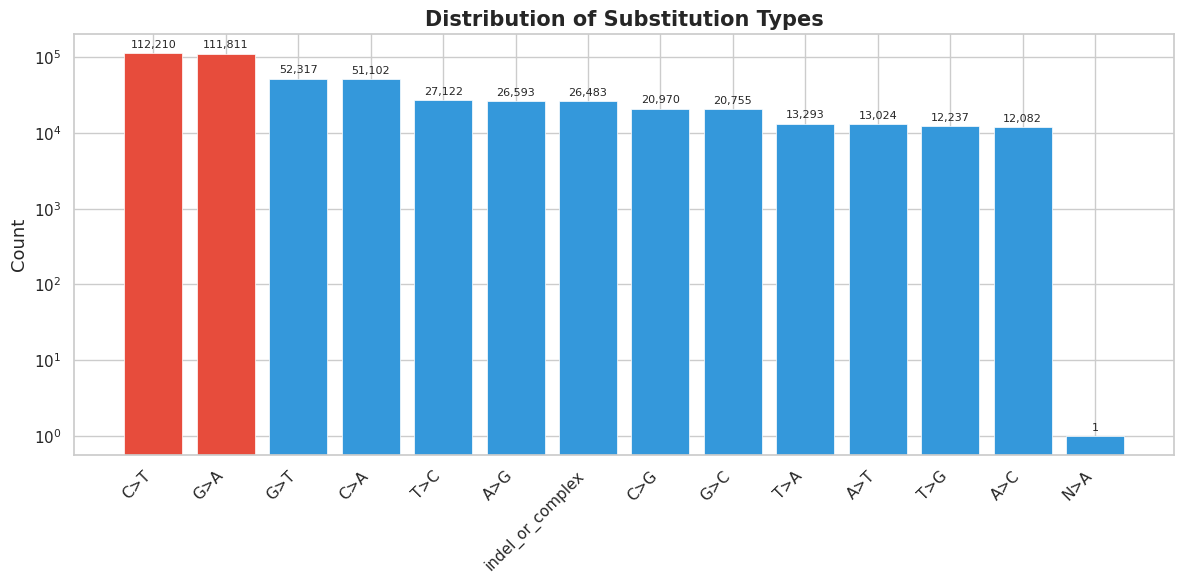

In [4]:
# --- Substitution Type Distribution ---
sub_counts = gsm_df['SUBSTITUTION_TYPE'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if 'C>T' in x or 'G>A' in x else '#3498db' for x in sub_counts.index]
bars = ax.bar(range(len(sub_counts)), sub_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(sub_counts)))
ax.set_xticklabels(sub_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Distribution of Substitution Types', fontsize=15, fontweight='bold')
ax.set_yscale('log')

for bar_item, val in zip(bars, sub_counts.values):
    ax.text(bar_item.get_x() + bar_item.get_width()/2, val * 1.1,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CH4_DIR, 'substitution_type_distribution.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH4_DIR}/substitution_type_distribution.png')
plt.show()

✅ Saved: thesis_figures/ch4_data/chromosomal_distribution.png


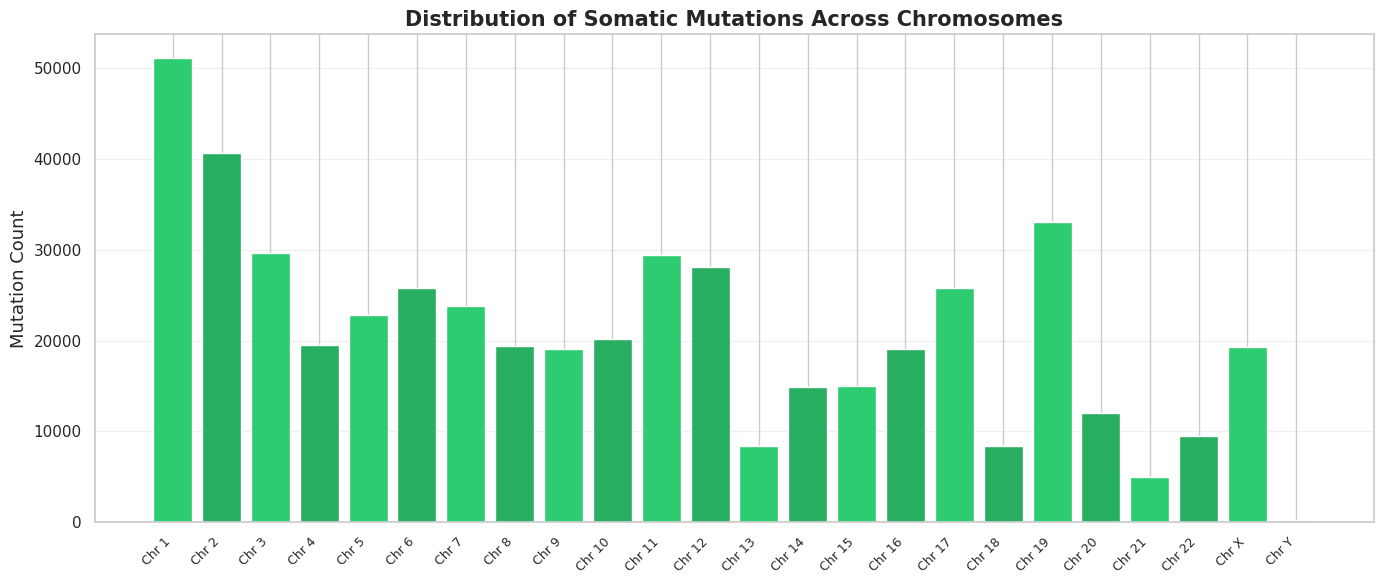

In [5]:
# --- Chromosomal Distribution ---
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
gsm_df['CHROMOSOME'] = gsm_df['CHROMOSOME'].astype(str)
chrom_counts = gsm_df['CHROMOSOME'].value_counts()

ordered_counts, ordered_labels = [], []
for c in chrom_order:
    if c in chrom_counts.index:
        ordered_counts.append(chrom_counts[c])
        ordered_labels.append(f'Chr {c}')

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['#2ecc71' if i % 2 == 0 else '#27ae60' for i in range(len(ordered_labels))]
ax.bar(range(len(ordered_labels)), ordered_counts, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mutation Count', fontsize=13)
ax.set_title('Distribution of Somatic Mutations Across Chromosomes', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CH4_DIR, 'chromosomal_distribution.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH4_DIR}/chromosomal_distribution.png')
plt.show()

✅ Saved: thesis_figures/ch4_data/missing_data.png


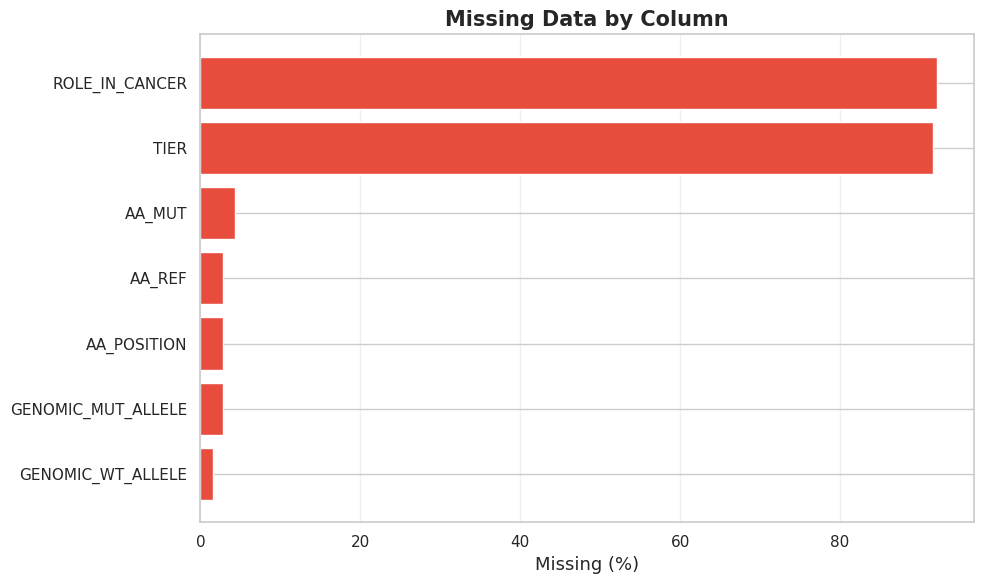

In [6]:
# --- Missing Data ---
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct = (gsm_df.isnull().sum() / len(gsm_df) * 100).sort_values(ascending=False)
cols_with_missing = missing_pct[missing_pct > 0]

if len(cols_with_missing) > 0:
    ax.barh(range(len(cols_with_missing)), cols_with_missing.values, color='#e74c3c', edgecolor='white')
    ax.set_yticks(range(len(cols_with_missing)))
    ax.set_yticklabels(cols_with_missing.index, fontsize=11)
    ax.set_xlabel('Missing (%)', fontsize=13)
    ax.set_title('Missing Data by Column', fontsize=15, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CH4_DIR, 'missing_data.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH4_DIR}/missing_data.png')
plt.show()

✅ Saved: thesis_figures/ch4_data/gene_frequency_driver_vs_passenger.png


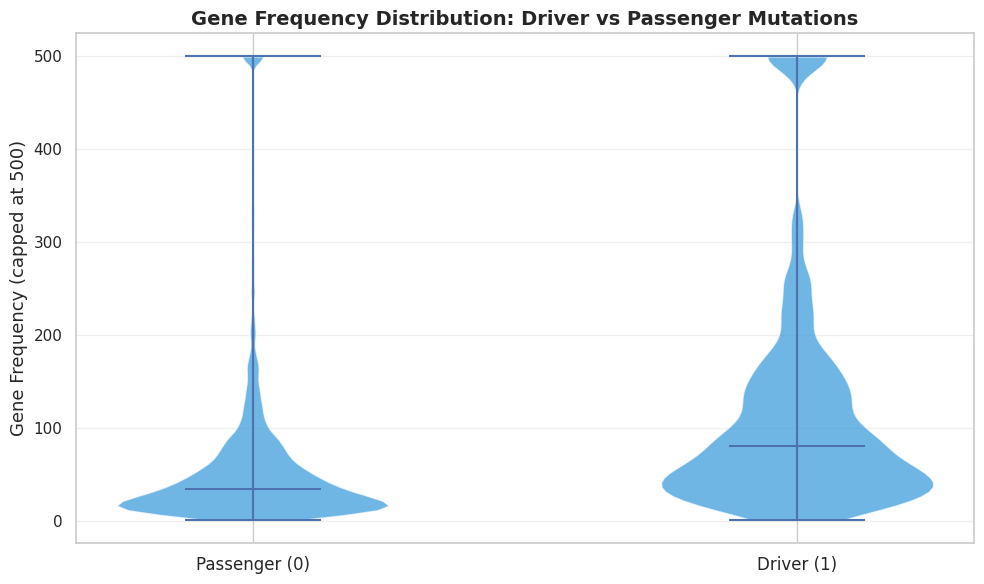

In [7]:
# --- Gene Frequency: Driver vs Passenger ---
fig, ax = plt.subplots(figsize=(10, 6))
driver_freq = X_train.loc[y_train == 1, 'gene_frequency']
passenger_freq = X_train.loc[y_train == 0, 'gene_frequency']

parts = ax.violinplot(
    [passenger_freq.clip(upper=500), driver_freq.clip(upper=500)],
    positions=[0, 1], showmedians=True, showextrema=True
)
for pc in parts['bodies']:
    pc.set_facecolor('#3498db')
    pc.set_alpha(0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Passenger (0)', 'Driver (1)'], fontsize=12)
ax.set_ylabel('Gene Frequency (capped at 500)', fontsize=13)
ax.set_title('Gene Frequency Distribution: Driver vs Passenger Mutations',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CH4_DIR, 'gene_frequency_driver_vs_passenger.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH4_DIR}/gene_frequency_driver_vs_passenger.png')
plt.show()

## 5. Model Training
Train XGBoost and LightGBM (matching the main notebook) to generate results figures.

In [8]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
print(f'Class ratio: {neg}/{pos} = {neg/pos:.1f}x')

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=neg/pos, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, sample_weight=w_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
print('XGBoost trained.')

# LightGBM
lgbm_model = LGBMClassifier(
    class_weight='balanced', n_estimators=200,
    learning_rate=0.1, random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train, sample_weight=w_train)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]
print('LightGBM trained.')

Class ratio: 368569/31431 = 11.7x
XGBoost trained.
LightGBM trained.


## 6. Chapter 6 Figures — Results

✅ Saved: thesis_figures/ch6_results/threshold_optimization.png


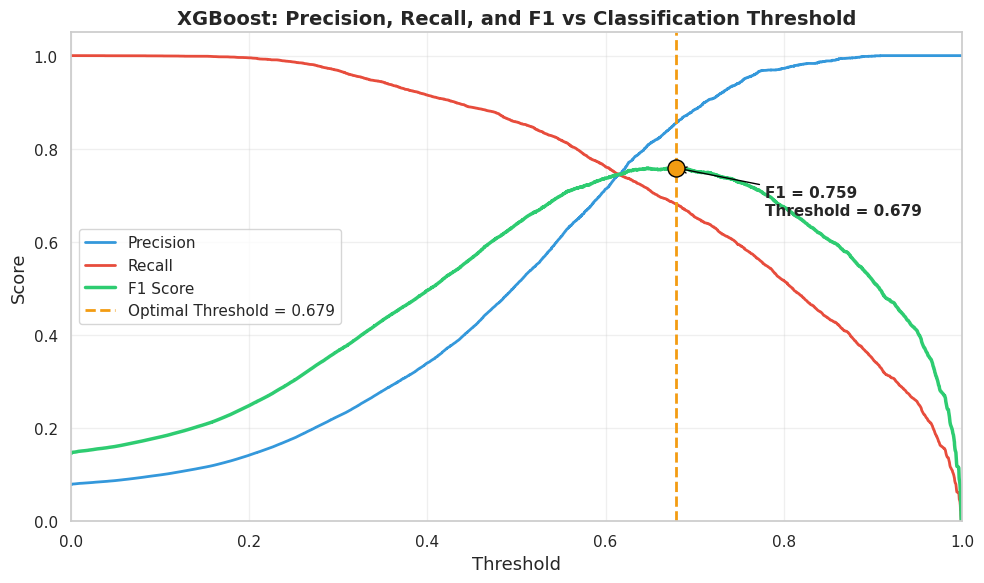

In [9]:
# --- Threshold Optimization Plot ---
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, xgb_prob)
f1_arr = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
best_idx = np.argmax(f1_arr[:-1])
best_thresh = thresholds[best_idx]
best_f1 = f1_arr[best_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision_curve[:-1], label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds, recall_curve[:-1], label='Recall', color='#e74c3c', linewidth=2)
ax.plot(thresholds, f1_arr[:-1], label='F1 Score', color='#2ecc71', linewidth=2.5)
ax.axvline(x=best_thresh, color='#f39c12', linestyle='--', linewidth=2,
           label=f'Optimal Threshold = {best_thresh:.3f}')
ax.scatter([best_thresh], [best_f1], color='#f39c12', s=150, zorder=5, edgecolors='black')
ax.annotate(f'F1 = {best_f1:.3f}\nThreshold = {best_thresh:.3f}',
            xy=(best_thresh, best_f1), xytext=(best_thresh + 0.1, best_f1 - 0.1),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('Threshold', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('XGBoost: Precision, Recall, and F1 vs Classification Threshold',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(CH6_DIR, 'threshold_optimization.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH6_DIR}/threshold_optimization.png')
plt.show()

✅ Saved: thesis_figures/ch6_results/confusion_matrix_lgbm.png


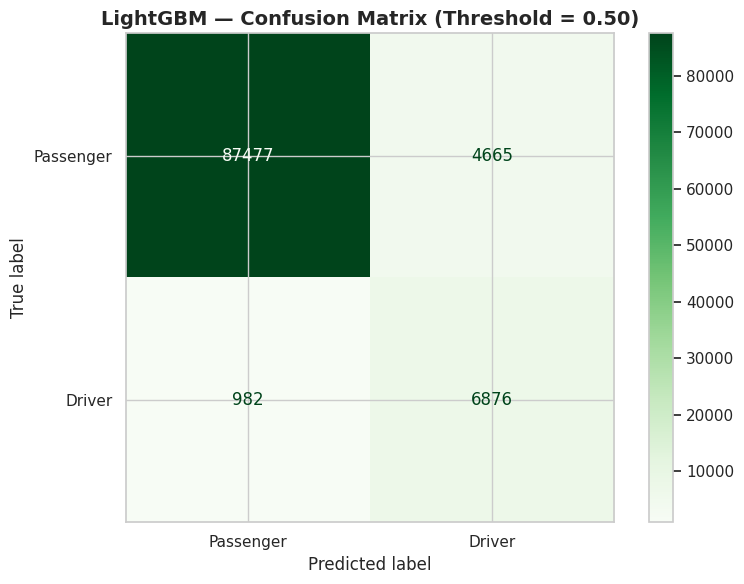

In [10]:
# --- LightGBM Confusion Matrix ---
lgbm_pred = (lgbm_prob >= 0.5).astype(int)
cm_lgbm = confusion_matrix(y_test, lgbm_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=['Passenger', 'Driver'])
disp.plot(cmap=plt.cm.Greens, ax=ax)
ax.set_title('LightGBM — Confusion Matrix (Threshold = 0.50)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CH6_DIR, 'confusion_matrix_lgbm.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH6_DIR}/confusion_matrix_lgbm.png')
plt.show()

✅ Saved: thesis_figures/ch6_results/xgboost_feature_importance.png


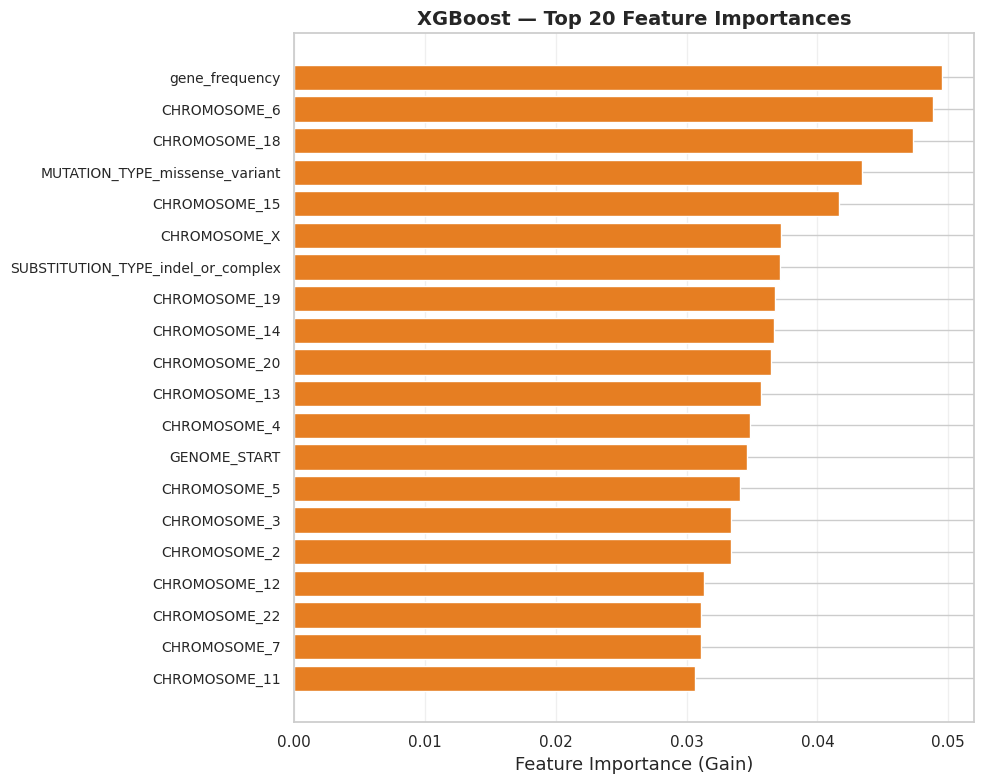

In [11]:
# --- XGBoost Feature Importance (Native) ---
importances = xgb_model.feature_importances_
feat_names = X_train.columns
sorted_idx = np.argsort(importances)[-20:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='#e67e22', edgecolor='white')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feat_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=13)
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CH6_DIR, 'xgboost_feature_importance.png'), dpi=150, bbox_inches='tight')
print(f'✅ Saved: {CH6_DIR}/xgboost_feature_importance.png')
plt.show()

## ✅ Complete!
All thesis figures have been generated and saved to `thesis_figures/`:

| Chapter | Figures |
|---------|--------|
| **Ch4 — Data** | Substitution type distribution, Chromosomal distribution, Missing data, Gene frequency violin |
| **Ch5 — Methodology** | Pipeline architecture (generated separately via image tool) |
| **Ch6 — Results** | Threshold optimization, LightGBM confusion matrix, XGBoost feature importance |

Combined with the existing figures from the main notebook, this gives ~19 total figures for the thesis.